# Step 6: Neural Network & PyTorch

In [132]:
# 追加ライブラリ
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation

## tensor.py

In [133]:
import torch

x = torch.tensor(5.0, requires_grad=True)
y = 3 * x ** 2
print(y)

y.backward()    # 逆伝播を計算   
print(x.grad)   # dy/dx = 6 * x = 30 となるはず

tensor(75., grad_fn=<MulBackward0>)
tensor(30.)


## Rosenbrock function

$$
y = 100(x_1-x_0^2)^2 + (x_0-1)^2
$$

In [134]:
import numpy as np

def rosenbrock(x0, x1):
    y = 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2
    return y

x0 = np.linspace(-2, 2, 400)
x1 = np.linspace(-1, 3, 400)
x0_grid, x1_grid = np.meshgrid(x0, x1)
y_grid = rosenbrock(x0_grid, x1_grid)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis', alpha=0.8)
fig.colorbar(surf, ax=ax, shrink=0.5, label='y (Rosenbrock value)')

ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('Rosenbrock Function')
plt.show()

In [ ]:
if False:
    # 水平方向の角度として利用する値を指定
    h_vals = np.arange(0.0, 360.0, step=5.0)

    # フレーム数を設定
    frame_num = len(h_vals)

    # 図を初期化
    fig = plt.figure(figsize=(10, 7), facecolor='white')
    ax = fig.add_subplot(projection='3d') # 3D用の設定
    fig.suptitle('Rosenbrock function', fontsize=20)
        
    # 作図処理を関数として定義
    def update(i):
        # 前フレームのグラフを初期化
        plt.cla()
        
        # i番目の角度を取得
        h = h_vals[i]
        
        # ローゼンブロック関数の曲面図を描画
        ax.contour(x0_grid, x1_grid, y_grid, 
                norm=LogNorm(), levels=levs, offset=0.0) # 等高線
        ax.plot_surface(x0_grid, x1_grid, y_grid, 
                        norm=LogNorm(), cmap='viridis', alpha=0.8) # 曲面
        ax.scatter(1.0, 1.0, rosenbrock(1.0, 1.0), 
                marker='*', s=300, c='red',
                label='minimum (1.0, 1.0)') # 最小値
        ax.legend(loc='upper right')
        ax.set_xlabel('$x_0$', fontsize=15)
        ax.set_ylabel('$x_1$', fontsize=15)
        ax.set_zlabel('f(x)', fontsize=15)
        ax.set_box_aspect(aspect=(1, 1, 1))
        ax.view_init(elev=40, azim=h) # 表示角度

    # gif画像を作成
    ani = FuncAnimation(fig=fig, func=update, frames=frame_num, interval=100)

    # gif画像を保存
    ani.save('rosenbrock.gif')

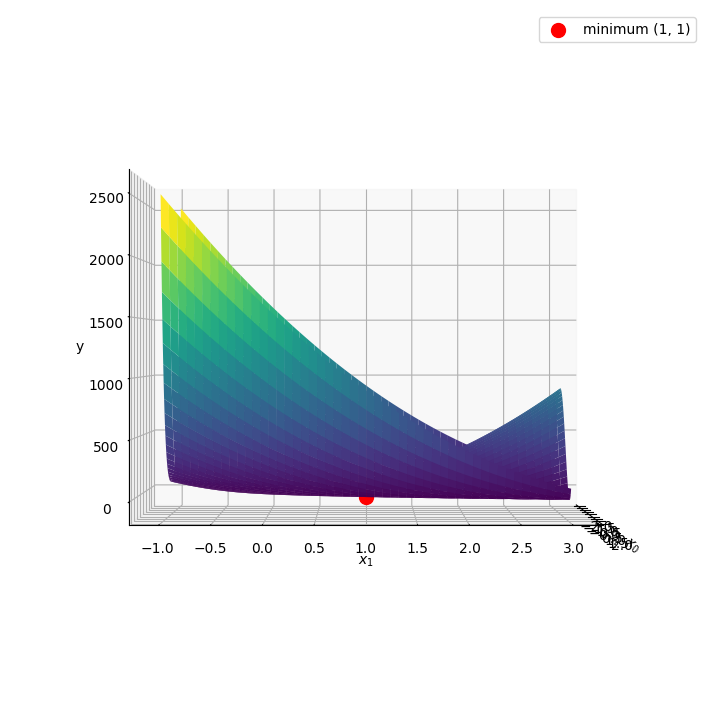

In [ ]:
from matplotlib.colors import LogNorm

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis') # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.view_init(elev=0, azim=0) # 表示アングル
plt.show()

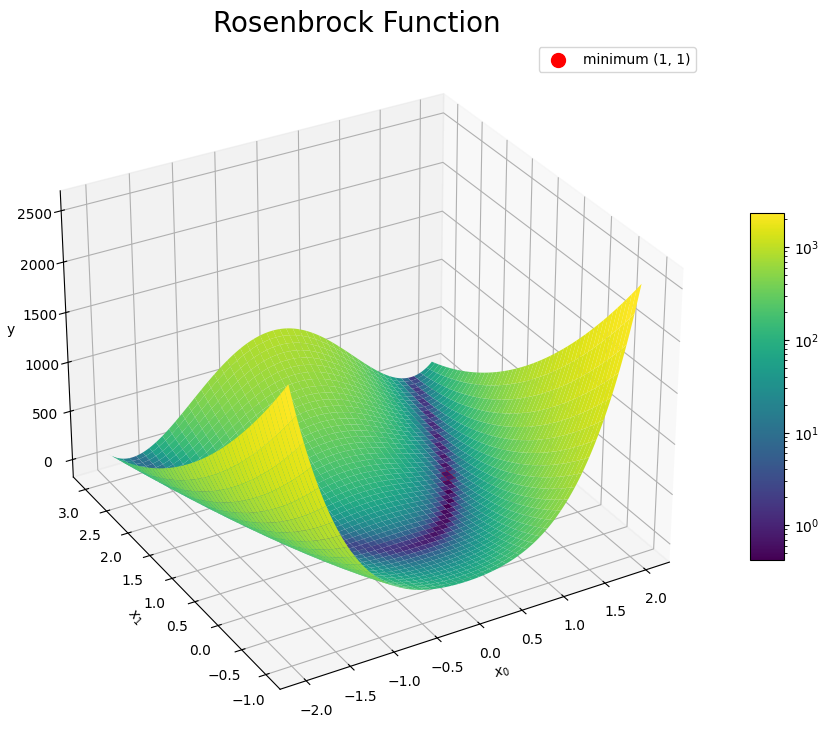

In [ ]:
from matplotlib.colors import LogNorm

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis', norm=LogNorm()) # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.set_title('Rosenbrock Function', fontsize=20) # タイトル
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=30, azim=240) # 表示アングル
plt.show()

## gradient.py

In [ ]:
import torch

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

y = rosenbrock(x0, x1)
y.backward()
print(x0.grad, x1.grad)

tensor(-2.) tensor(400.)


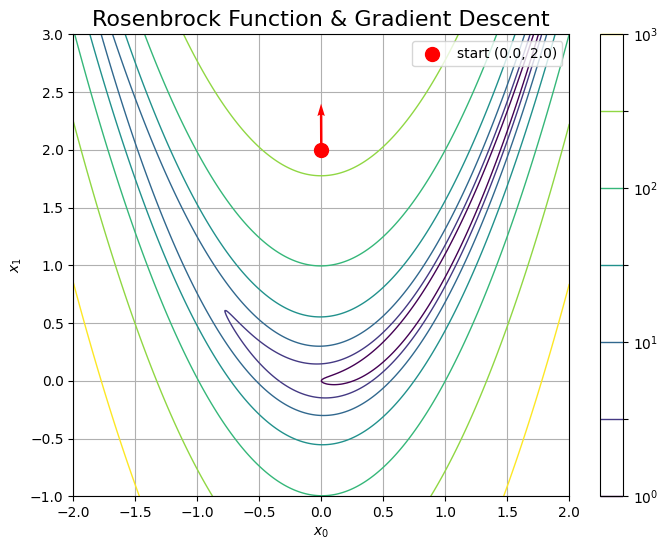

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

start_point = (0.0, 2.0)  # 初期点

# 勾配を計算 (PyTorchで自動微分)
x0_t = torch.tensor(start_point[0], requires_grad=True)
x1_t = torch.tensor(start_point[1], requires_grad=True)
y_t = rosenbrock(x0_t, x1_t)
y_t.backward()
g0 = x0_t.grad.item()  
g1 = x1_t.grad.item()  

# 矢印の長さを正規化 (プロット範囲に合わせてスケール)
g_norm = (g0**2 + g1**2) ** 0.5
scale = 0.4  # 表示上の矢印の長さ (軸単位)
dq0 = scale * g0 / g_norm
dq1 = scale * g1 / g_norm

# 等高線
levs = 10**np.arange(0., 3.5, 0.5)

# プロット
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(x0_grid, x1_grid, y_grid, levels=levs, norm=LogNorm(), cmap='viridis', linewidths=1)
plt.colorbar(contour)

ax.scatter(start_point[0], start_point[1], color='red', s=100, zorder=5, label='start ({}, {})'.format(start_point[0], start_point[1]))
ax.quiver(start_point[0], start_point[1], dq0, dq1, angles='xy', scale_units='xy', scale=1,
          color='red', width=0.005, zorder=6)
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Rosenbrock Function & Gradient Descent', fontsize=16)
ax.legend()
plt.grid()
plt.show()

## 勾配法を用いた関数の最小点の探索
$$
x_0 \leftarrow x_0 - \eta \cfrac{\partial y}{\partial x_0}
$$
$$
x_1 \leftarrow x_1 - \eta \cfrac{\partial y}{\partial x_1}
$$

In [ ]:
lr = 0.001  # learning rate
iters = 10000  # iteration count

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

history = [(x0.item(), x1.item())]  # 初期点を履歴に追加

# 勾配法の更新処理
def run_gradient(x0, x1, lr, iters, history, display_interval=True):
    for i in range(iters):
        if i % 1000 == 0 and display_interval:
            print(f"{x0.item():.7f}, {x1.item():.7f}") # float32 の仮数部は 23 bit なので有効数字は約7桁(2^23 ≈ 10^7.2)
        y = rosenbrock(x0, x1)

        y.backward()

        x0.data -= lr * x0.grad.data
        x1.data -= lr * x1.grad.data

        x0.grad.zero_()
        x1.grad.zero_()

        history.append((x0.item(), x1.item()))

run_gradient(x0, x1, lr, iters, history)
print(f"{x0.item():.7f}, {x1.item():.7f}") 

0.0000000, 2.0000000


0.6837119, 0.4659528
0.8263181, 0.6820318
0.8947841, 0.8001903
0.9334872, 0.8711215
0.9569893, 0.9156519
0.9718162, 0.9443122
0.9813805, 0.9630323
0.9876351, 0.9753732
0.9917611, 0.9835569
0.9944981, 0.9890044


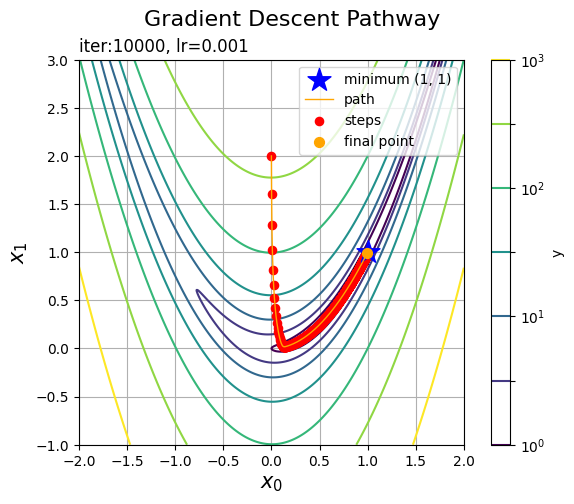

In [ ]:
xs, ys = zip(*history)

def display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr, ax=None, show_legend=True):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
        fig.suptitle('Gradient Descent Pathway', fontsize=16)
    cnt = ax.contour(x0_grid, x1_grid, y_grid, norm=LogNorm(), levels=levs, zorder=2)
    ax.scatter(1.0, 1.0, marker='*', s=300, c='blue', label='minimum (1, 1)', zorder=4)
    ax.plot(xs, ys,c='orange',linewidth=1,zorder=4,label='path')
    ax.scatter(xs, ys,c='red',s=35,zorder=3,label='steps')
    ax.scatter(xs[-1], ys[-1], marker='o', s=50, c='orange', edgecolors='orange', zorder=5, label='final point')
    ax.set_xlabel('$x_0$', fontsize=15)
    ax.set_ylabel('$x_1$', fontsize=15)
    ax.set_title('iteration:' + str(iters) + ', lr=' + str(lr), loc='left')
    plt.colorbar(cnt, ax=ax, label='y')
    ax.grid(zorder=0)
    ax.set_aspect('equal')
    if show_legend:
        ax.legend()
    if standalone:
        plt.show()

display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr)

## 勾配法 - lrによる比較

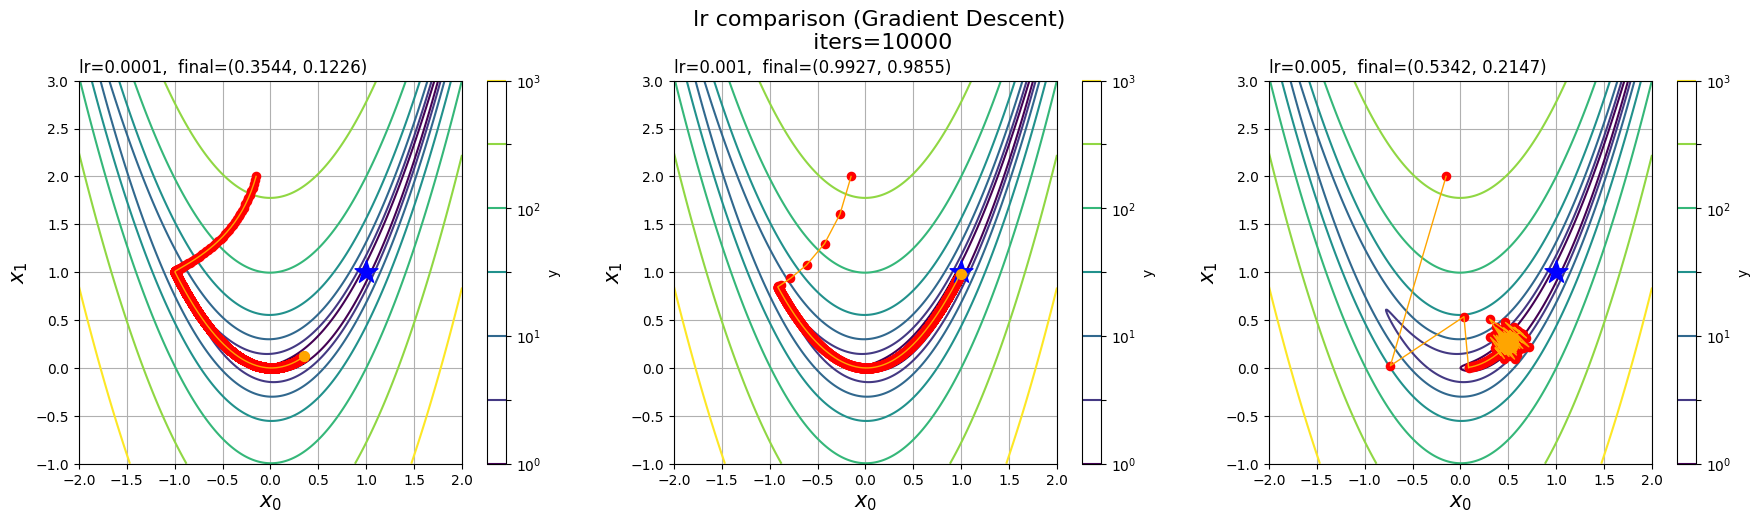

In [ ]:
import torch
from matplotlib.colors import LogNorm

start_point = (-0.15, 2.0)  # 初期点

lr_list = [0.0001, 0.001, 0.005]
iters = 10000

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('lr comparison (Gradient Descent)\n iters=' + str(iters), fontsize=16)

for ax, lr in zip(axes, lr_list):
    x0 = torch.tensor(start_point[0], requires_grad=True)
    x1 = torch.tensor(start_point[1], requires_grad=True)
    history = [(x0.item(), x1.item())]
    run_gradient(x0, x1, lr, iters, history, display_interval=False)
    xs, ys = zip(*history)
    display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr, ax=ax, show_legend=False)
    ax.set_title(f'lr={lr},  final=({xs[-1]:.4f}, {ys[-1]:.4f})', loc='left')

plt.tight_layout()
plt.show()

## 勾配法 - start_pointによる比較

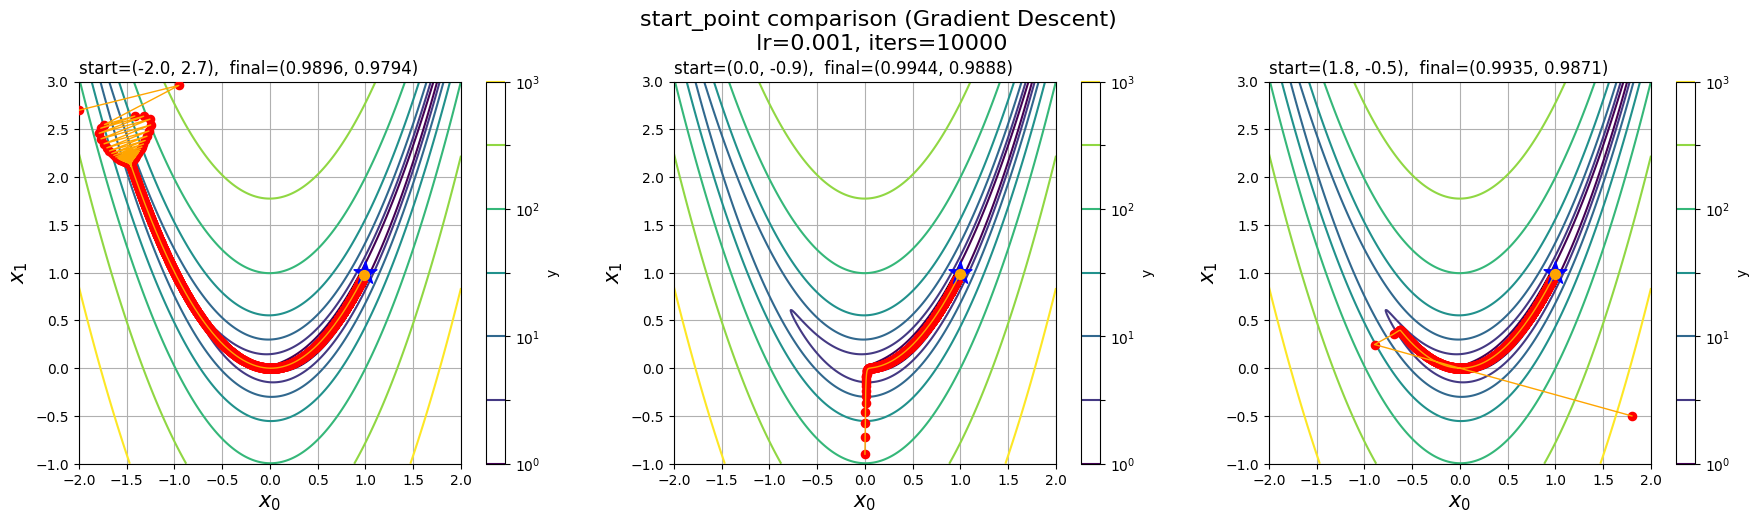

In [ ]:
import torch
from matplotlib.colors import LogNorm

lr = 0.001
iters = 10000

start_points = [(-2.0, 2.7), (0.0, -0.9), (1.8, -0.5)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('start_point comparison (Gradient Descent)\n lr=' + str(lr) + ', iters=' + str(iters), fontsize=16)

for ax, start_point in zip(axes, start_points):
    x0 = torch.tensor(start_point[0], requires_grad=True)
    x1 = torch.tensor(start_point[1], requires_grad=True)
    history = [(x0.item(), x1.item())]
    run_gradient(x0, x1, lr, iters, history, display_interval=False)
    xs, ys = zip(*history)
    display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr, ax=ax, show_legend=False)
    ax.set_title(f'start={start_point},  final=({xs[-1]:.4f}, {ys[-1]:.4f})', loc='left')

plt.tight_layout()
plt.show()

---

## 線形回帰 $\hat{y}=Wx+b$ 
### 損失関数

$$
L(W,b) = \frac{1}{N}\sum_{i=1}^{N}(y_i - (Wx_i+b))^2
$$

データ点 $(x_1, y_1)$ が given で、$W$ と $b$ が変数. 

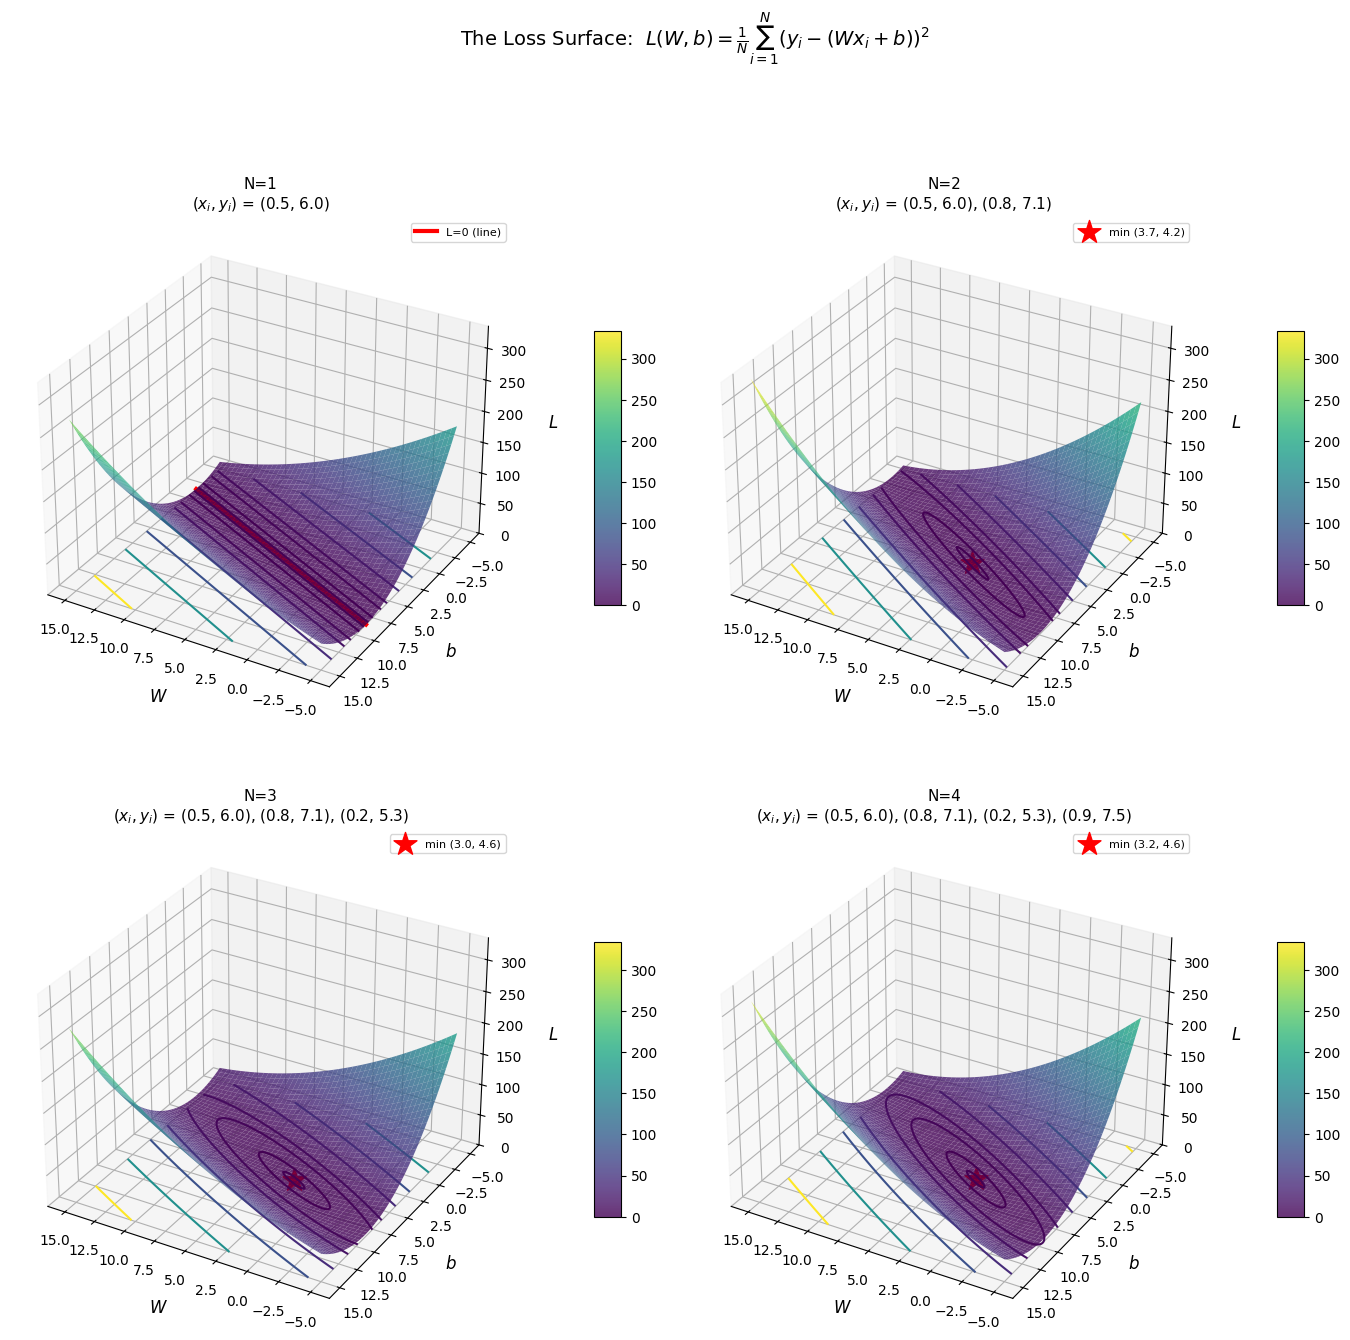

In [ ]:
# データ点を増やしたときの損失曲面の変化を可視化
# L(W,b) = (1/N) * Σ(yi - (W*xi + b))^2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# データ点リスト (順に追加していく)
data_points = [(0.5, 6.0), (0.8, 7.1), (0.2, 5.3), (0.9, 7.5)]

W_range = np.linspace(-5, 15, 200)
b_range = np.linspace(-5, 15, 200)
W_grid, b_grid = np.meshgrid(W_range, b_range)

levs = np.array([0.1, 1, 5, 10, 25, 50, 100, 200])

# 全パネルの損失グリッドを先に計算し、最大値を取得
L_grids = []
for idx in range(len(data_points)):
    pts = data_points[:idx + 1]
    L_grid = np.zeros_like(W_grid)
    for xi, yi in pts:
        L_grid += (yi - (W_grid * xi + b_grid)) ** 2
    L_grid /= len(pts)
    L_grids.append(L_grid)

vmin = 0.0
vmax = max(L.max() for L in L_grids)
norm = Normalize(vmin=vmin, vmax=vmax)

n_plots = len(data_points)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig = plt.figure(figsize=(14, 7 * n_rows))

for idx in range(n_plots):
    pts = data_points[:idx + 1]
    xs = np.array([p[0] for p in pts])
    ys = np.array([p[1] for p in pts])
    N = len(pts)
    L_grid = L_grids[idx]

    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')

    # 等高線（底面に投影）
    ax.contour(W_grid, b_grid, L_grid, levels=levs, cmap='viridis', offset=0.0)

    # 3D曲面（共通のnormで色を統一）
    surf = ax.plot_surface(W_grid, b_grid, L_grid, cmap='viridis', alpha=0.8, norm=norm)

    # L最小の点/直線を描画
    if N == 1:
        W_line = np.linspace(-5, 15, 100)
        b_line = ys[0] - xs[0] * W_line
        ax.plot(W_line, b_line, np.zeros_like(W_line), 'r-', linewidth=3, label='L=0 (line)')
    else:
        coeffs = np.polyfit(xs, ys, 1)
        W_opt, b_opt = coeffs[0], coeffs[1]
        L_opt = np.mean((ys - (W_opt * xs + b_opt)) ** 2)
        ax.scatter(W_opt, b_opt, L_opt, marker='*', s=300, c='red', zorder=5,
                   label=f'min ({W_opt:.1f}, {b_opt:.1f})')

    ax.set_xlabel('$W$', fontsize=12, labelpad=8)
    ax.set_ylabel('$b$', fontsize=12, labelpad=8)
    ax.set_zlabel('$L$', fontsize=12, labelpad=10)
    ax.set_zlim(0, vmax)

    pts_str = ', '.join([f'({xi}, {yi})' for xi, yi in pts])
    ax.set_title(f'N={N}\n$(x_i, y_i)$ = {pts_str}', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
    ax.view_init(elev=30, azim=120)
    fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, pad=0.12)

fig.suptitle(r'The Loss Surface: $L(W,b) = \frac{1}{N}\sum_{i=1}^{N}(y_i - (Wx_i+b))^2$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

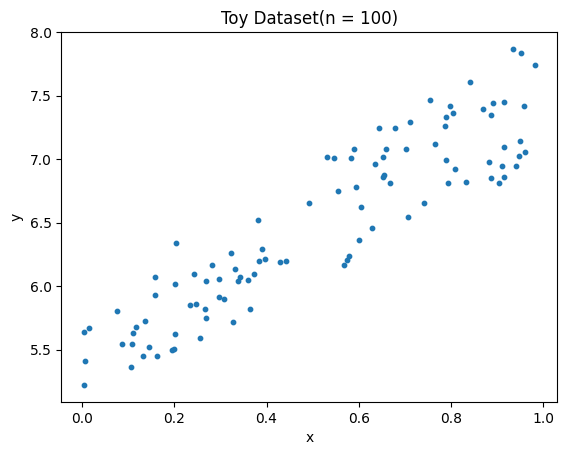

In [ ]:
import torch

n = 100
torch.manual_seed(42)
x = torch.rand(n, 1)
y = 5 + 2 * x + torch.rand(n, 1)  # 一様分布から生成. y = 5 + 2 * x + ε

plt.scatter(x.numpy(), y.numpy(), s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Toy Dataset(n = {n})')
plt.show()

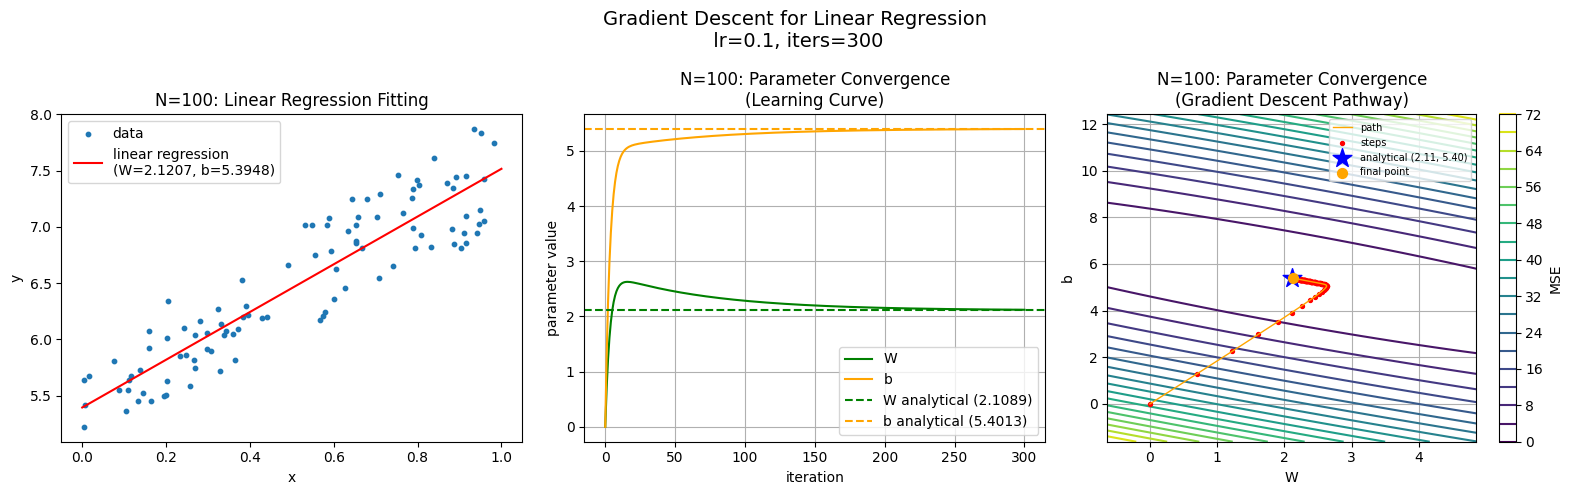

In [ ]:
import torch
import numpy as np

# cell-24でグローバル変数が上書きされるため、データを再定義
n = 100
torch.manual_seed(42)
x = torch.rand(n, 1)
y = 5 + 2 * x + torch.rand(n, 1)

def predict(x, W, b):
    y = x @ W + b
    return y

def mean_squared_error(x0, x1):
    diff = x0 - x1
    N = len(diff)
    return torch.sum(diff ** 2) / N

def run_toy_gradient_descent(x, y, lr=0.1, iters=100, W_init=0.0, b_init=0.0):
    W = torch.tensor([[W_init]], dtype=torch.float32, requires_grad=True)
    b = torch.tensor([b_init], dtype=torch.float32, requires_grad=True)

    W_history = [W.item()]
    b_history = [b.item()]

    for i in range(iters):
        y_hat = predict(x, W, b)
        loss = mean_squared_error(y, y_hat)

        loss.backward()

        W.data -= lr * W.grad.data
        b.data -= lr * b.grad.data

        W.grad.zero_()
        b.grad.zero_()

        W_history.append(W.item())
        b_history.append(b.item())

    return W_history, b_history

def compute_loss_landscape(x, y, W_range, b_range):
    """W-b平面上のMSE損失のグリッドを計算"""
    loss_grid = np.zeros((len(b_range), len(W_range)))
    for i, b_val in enumerate(b_range):
        for j, W_val in enumerate(W_range):
            y_hat = x.numpy() * W_val + b_val
            diff = y.numpy() - y_hat
            loss_grid[i, j] = np.sum(diff ** 2) / len(diff)
    return loss_grid

def display_toy_gradient_descent(ax1, ax2, ax3, x, y, W_hist, b_hist, W_an, b_an, N, iters, y_lim=None):
    W_final = W_hist[-1]
    b_final = b_hist[-1]

    # left: scatter + fit line
    ax1.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
    x_line = torch.tensor([[0.0], [1.0]])
    y_line = W_final * x_line.detach().numpy() + b_final
    ax1.plot(x_line, y_line, color='red')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(f'N={N}: Linear Regression Fitting')
    ax1.legend(['data', f'linear regression\n(W={W_final:.4f}, b={b_final:.4f})'])

    # center: convergence to analytical solution
    if y_lim is not None:
        ax2.set_ylim(y_lim)
    ax2.plot(range(iters + 1), W_hist, color='green', label='W')
    ax2.plot(range(iters + 1), b_hist, color='orange', label='b')
    ax2.axhline(W_an, color='green', linestyle='--', label=f'W analytical ({W_an:.4f})')
    ax2.axhline(b_an, color='orange', linestyle='--', label=f'b analytical ({b_an:.4f})')
    ax2.set_xlabel('iteration')
    ax2.set_ylabel('parameter value')
    ax2.set_title(f'N={N}: Parameter Convergence\n(Learning Curve)')
    ax2.legend()
    ax2.grid()

    # right: gradient descent pathway on W-b loss landscape
    all_W = np.array(W_hist)
    all_b = np.array(b_hist)
    W_margin = max(abs(all_W.max() - W_an), abs(all_W.min() - W_an), 1.0) * 1.3
    b_margin = max(abs(all_b.max() - b_an), abs(all_b.min() - b_an), 1.0) * 1.3
    W_range = np.linspace(W_an - W_margin, W_an + W_margin, 150)
    b_range = np.linspace(b_an - b_margin, b_an + b_margin, 150)
    W_grid, b_grid = np.meshgrid(W_range, b_range)
    loss_grid = compute_loss_landscape(x, y, W_range, b_range)

    cnt = ax3.contour(W_grid, b_grid, loss_grid, levels=20, cmap='viridis', zorder=2)
    plt.colorbar(cnt, ax=ax3, label='MSE')
    ax3.plot(all_W, all_b, c='orange', linewidth=1, zorder=4, label='path')
    ax3.scatter(all_W, all_b, c='red', s=8, zorder=3, label='steps')
    ax3.scatter(W_an, b_an, marker='*', s=200, c='blue', zorder=5, label=f'analytical ({W_an:.2f}, {b_an:.2f})')
    ax3.scatter(all_W[-1], all_b[-1], marker='o', s=50, c='orange', edgecolors='orange', zorder=5, label='final point')
    ax3.set_xlabel('W')
    ax3.set_ylabel('b')
    ax3.set_title(f'N={N}: Parameter Convergence\n(Gradient Descent Pathway)')
    ax3.legend(fontsize=7)
    ax3.grid(zorder=0)

lr = 0.1
iters = 300

W_history, b_history = run_toy_gradient_descent(x, y, lr=lr, iters=iters)

coeffs = np.polyfit(x.detach().numpy().flatten(), y.detach().numpy().flatten(), 1)
W_an, b_an = coeffs[0], coeffs[1]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
display_toy_gradient_descent(ax1, ax2, ax3, x, y, W_history, b_history, W_an, b_an, len(x), iters)
fig.suptitle(f'Gradient Descent for Linear Regression\n lr={lr}, iters={iters}', fontsize=14)
plt.tight_layout()
plt.show()

## データ数による収束の比較

N=    10:  W=1.7201, b=5.8239  (analytical: W=1.7173, b=5.8258)
N=   100:  W=2.1097, b=5.4009  (analytical: W=2.1089, b=5.4013)
N=  1000:  W=1.9923, b=5.5073  (analytical: W=1.9915, b=5.5077)
N= 10000:  W=2.0065, b=5.4922  (analytical: W=2.0055, b=5.4927)


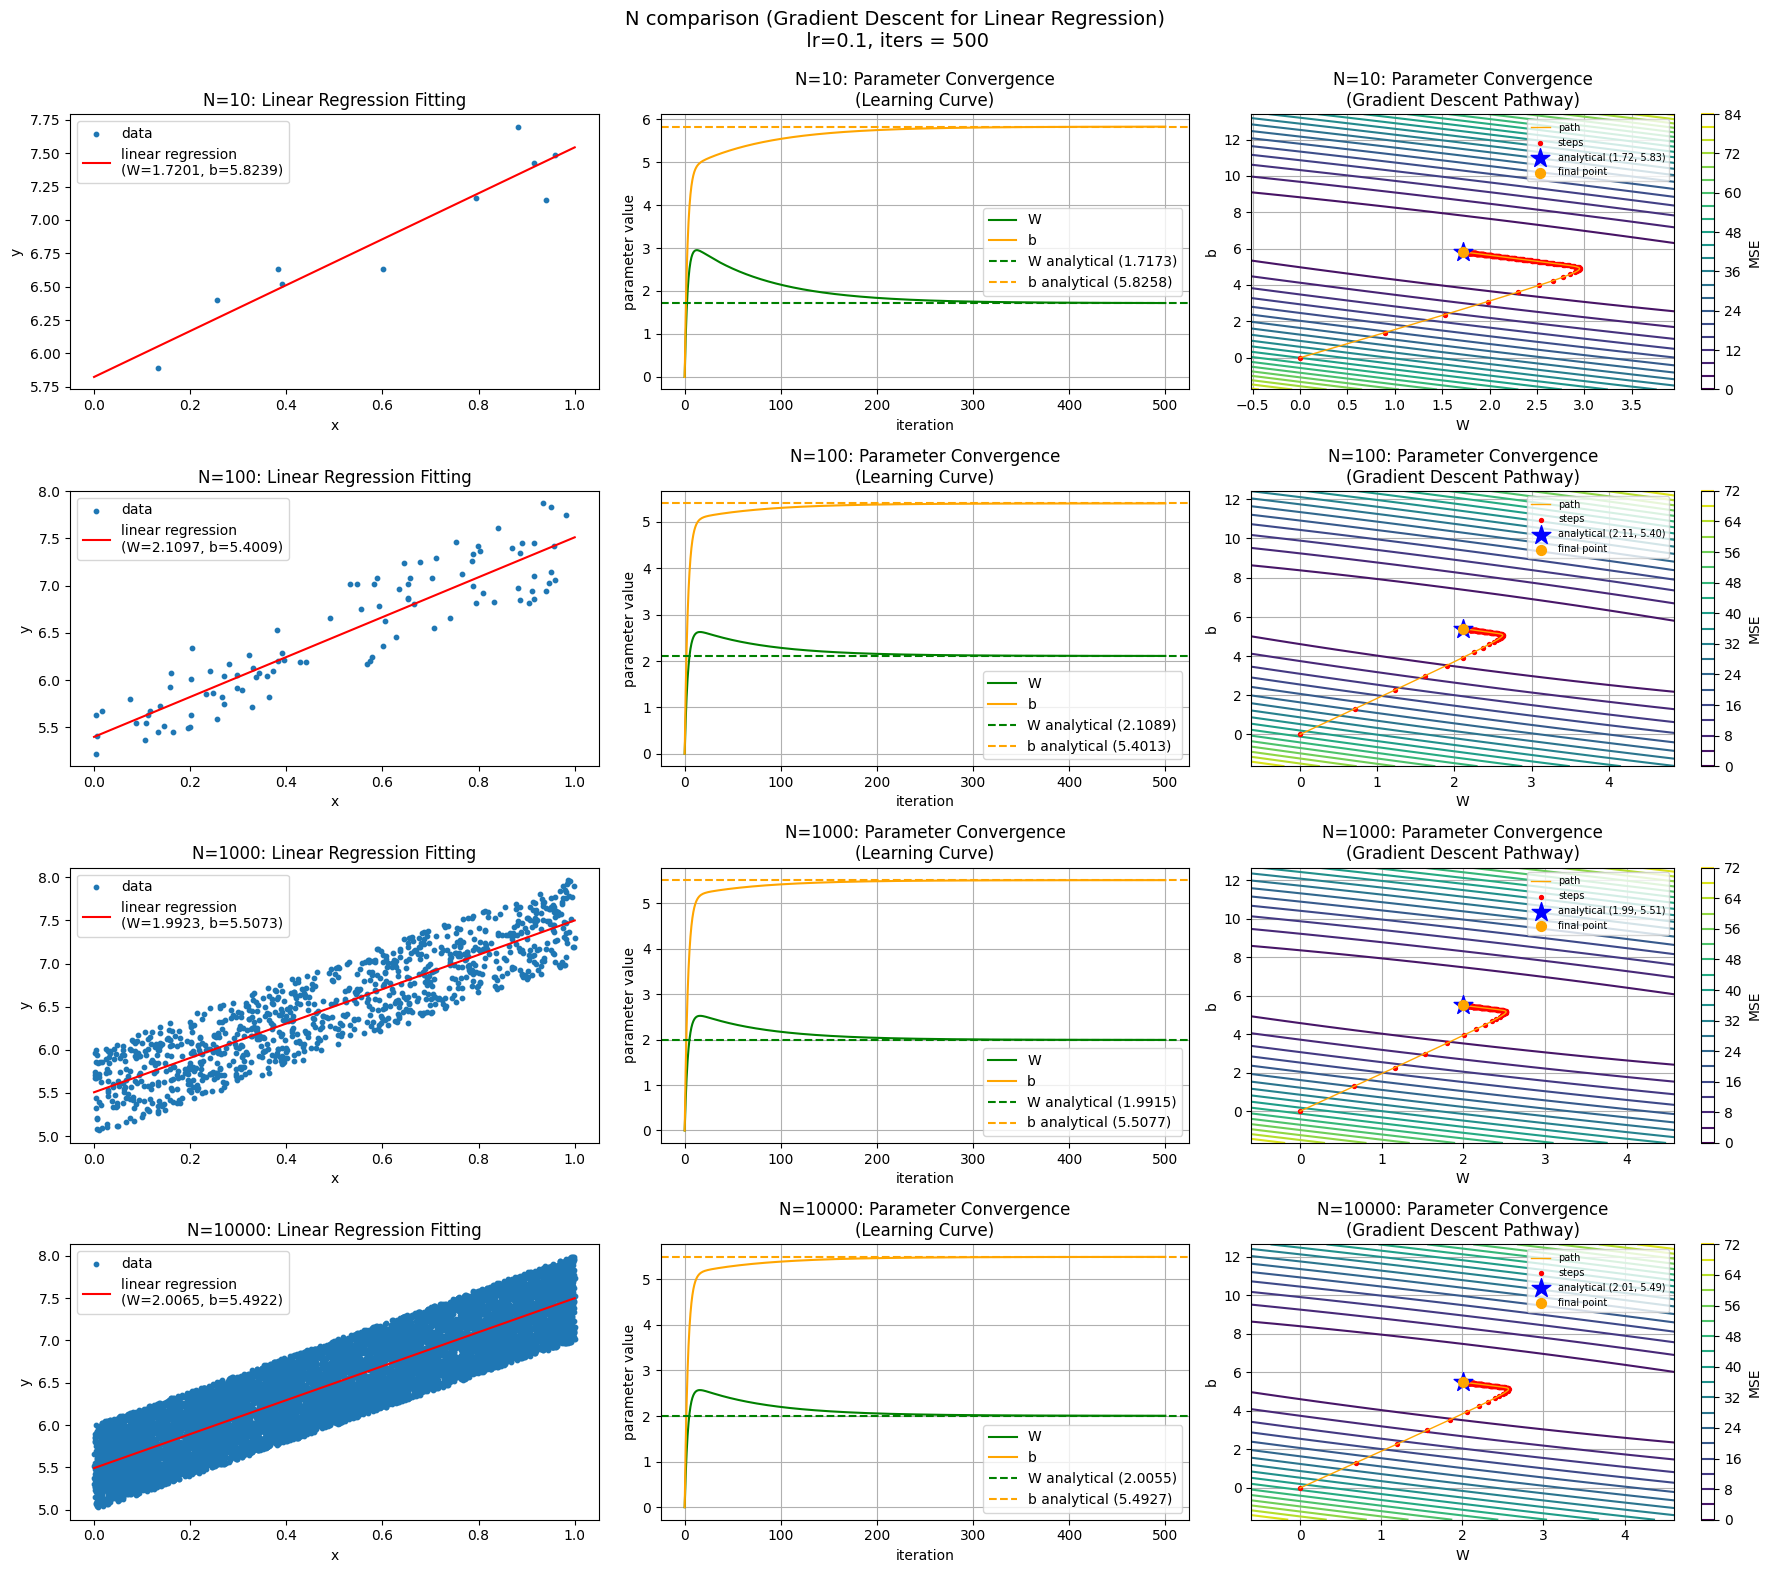

In [ ]:
# データ数を大きくすることで、W = 2, b = 5.5 (εの期待値は0.5) に近づくか？
import numpy as np

N_list = np.array([10, 100, 1000, 10000])
lr = 0.1
iters = 500

fig, axes = plt.subplots(len(N_list), 3, figsize=(18, 4 * len(N_list)))
fig.suptitle('N comparison (Gradient Descent for Linear Regression)\n lr={}'.format(lr)+', iters = {}\n'.format(iters), fontsize=14)

for row, N in enumerate(N_list):
    torch.manual_seed(42)
    x_n = torch.rand(N, 1)
    y_n = 5 + 2 * x_n + torch.rand(N, 1)

    coeffs = np.polyfit(x_n.numpy().flatten(), y_n.numpy().flatten(), 1)
    W_an, b_an = coeffs[0], coeffs[1]

    W_hist, b_hist = run_toy_gradient_descent(x_n, y_n, lr=lr, iters=iters)
    display_toy_gradient_descent(axes[row][0], axes[row][1], axes[row][2],
                                   x_n, y_n, W_hist, b_hist,
                                   W_an, b_an, N, iters)
    print(f'N={N:6d}:  W={W_hist[-1]:.4f}, b={b_hist[-1]:.4f}'
          f'  (analytical: W={W_an:.4f}, b={b_an:.4f})')

plt.tight_layout()
plt.show()

## 初期値による収束の比較

In [ ]:
import numpy as np

# cell-24でグローバル変数が上書きされるため、データを再定義
n = 100
torch.manual_seed(42)
x = torch.rand(n, 1)
y = 5 + 2 * x + torch.rand(n, 1)

init_list = np.array([(0.0, 0.0), (2.0, 5.0), (10.0, 0.0), (-5.0, 10.0)])
lr = 0.1
iters = 500

coeffs = np.polyfit(x.detach().numpy().flatten(), y.detach().numpy().flatten(), 1)
W_an, b_an = coeffs[0], coeffs[1]

# 1) 全初期値の履歴を先に計算
all_results = []
for W_init, b_init in init_list:
    W_hist, b_hist = run_toy_gradient_descent(x, y, lr=lr, iters=iters,
                                               W_init=W_init, b_init=b_init)
    all_results.append((W_hist, b_hist))

# 2) 全履歴から共通のW/b範囲を決定
all_W_vals = np.concatenate([np.array(r[0]) for r in all_results])
all_b_vals = np.concatenate([np.array(r[1]) for r in all_results])
# 解析解も含める
all_W_vals = np.append(all_W_vals, W_an)
all_b_vals = np.append(all_b_vals, b_an)

W_margin = (all_W_vals.max() - all_W_vals.min()) * 0.15
b_margin = (all_b_vals.max() - all_b_vals.min()) * 0.15
W_range = np.linspace(all_W_vals.min() - W_margin, all_W_vals.max() + W_margin, 150)
b_range = np.linspace(all_b_vals.min() - b_margin, all_b_vals.max() + b_margin, 150)

# 3) 損失ランドスケープを1回だけ計算
W_grid, b_grid = np.meshgrid(W_range, b_range)
loss_grid = compute_loss_landscape(x, y, W_range, b_range)

# 4) 描画
fig, axes = plt.subplots(len(init_list), 3, figsize=(18, 4 * len(init_list)))
fig.suptitle('Init position comparison (Gradient Descent for Linear Regression)\n'
             f'N = {len(x)}, lr = {lr}, iters = {iters}', fontsize=14)

# ダミーaxes (display_toy_gradient_descentの3列目描画を捨てるため)
fig_dummy, ax_dummy = plt.subplots()

for row, ((W_hist, b_hist), (W_init, b_init)) in enumerate(zip(all_results, init_list)):
    # 1,2列目のみ使い、3列目はダミーに描画させる
    display_toy_gradient_descent(axes[row][0], axes[row][1], ax_dummy,
                                 x, y, W_hist, b_hist,
                                 W_an, b_an, len(x), iters,
                                 y_lim=(np.min(init_list), np.max(init_list)))
    ax_dummy.cla()

    # 3列目を共通範囲で描画
    ax3 = axes[row][2]
    all_W = np.array(W_hist)
    all_b = np.array(b_hist)
    cnt = ax3.contour(W_grid, b_grid, loss_grid, levels=20, cmap='viridis', zorder=2)
    plt.colorbar(cnt, ax=ax3, label='MSE')
    ax3.plot(all_W, all_b, c='orange', linewidth=1, zorder=4, label='path')
    ax3.scatter(all_W, all_b, c='red', s=8, zorder=3, label='steps')
    ax3.scatter(W_an, b_an, marker='*', s=200, c='blue', zorder=5,
                label=f'analytical ({W_an:.2f}, {b_an:.2f})')
    ax3.scatter(all_W[-1], all_b[-1], marker='o', s=50, c='orange',
                edgecolors='orange', zorder=5, label='final point')
    ax3.set_xlim(W_range[0], W_range[-1])
    ax3.set_ylim(b_range[0], b_range[-1])
    ax3.set_xlabel('W')
    ax3.set_ylabel('b')
    ax3.set_title(f'Gradient Descent Pathway\n(W_init, b_init) = ({W_init}, {b_init})')
    ax3.legend(fontsize=7)
    ax3.grid(zorder=0)

    axes[row][0].set_title(f'Linear Regression Fitting\n(W_init, b_init) = ({W_init}, {b_init})')
    axes[row][1].set_title(f'Parameter Convergence\n(W_init, b_init) = ({W_init}, {b_init})')

    print(f'W_init={W_init:6.1f}, b_init={b_init:5.1f}:  '
          f'W={W_hist[-1]:.4f}, b={b_hist[-1]:.4f}'
          f'  (analytical: W={W_an:.4f}, b={b_an:.4f})')

plt.close(fig_dummy)
plt.tight_layout()
plt.show()

---

## neuralnet.py

0.7643452286720276
0.23656320571899414
0.2322607785463333
0.22441406548023224
0.21026141941547394
0.17957870662212372
0.11798439919948578
0.08477357029914856
0.08017147332429886
0.07964649796485901
0.07944130152463913


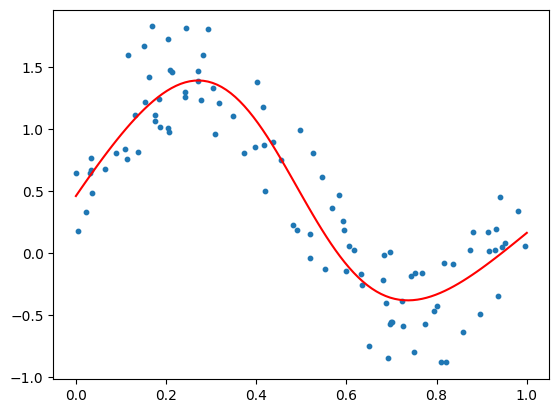

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


torch.manual_seed(0)
x = torch.rand(100, 1)
y = torch.sin(2 * torch.pi * x) + torch.rand(100, 1)

# model
class Model(nn.Module):
    def __init__(self, input_size=1, hidden_size= 10, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        y = self.linear1(x)
        y = F.sigmoid(y)
        y = self.linear2(y)
        return y


lr = 0.2
iters = 10000

model = Model()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

for i in range(iters):
    y_pred = model(x)
    loss = F.mse_loss(y, y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 1000 == 0:
        print(loss.item())

print(loss.item())

# plot
import matplotlib.pyplot as plt
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
x = torch.linspace(0, 1, 100).reshape(-1, 1)
y = model(x).detach().numpy()
plt.plot(x, y, color='red')
plt.show()

## vision.py

size: 60000
type: <class 'PIL.Image.Image'>
label: 5


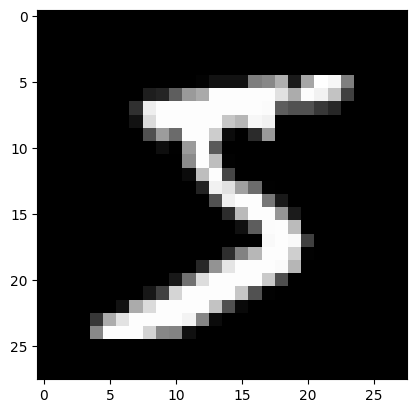

type: <class 'torch.Tensor'>
shape: torch.Size([1, 28, 28])
x shape: torch.Size([32, 1, 28, 28])
label shape: torch.Size([32])


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


## ==== MNIST ====
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=None,
    download=True
)

x, label = dataset[0]

print('size:', len(dataset))  # size: 60000
print('type:', type(x))  # type: <class 'PIL.Image.Image'>
print('label:', label)  # label: 5

plt.imshow(x, cmap='gray')
plt.show()


# ==== preprocess ====
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

x, label = dataset[0]
print('type:', type(x))  # type: <class 'torch.Tensor'>
print('shape:', x.shape)  # shape: torch.Size([1, 28, 28])


# ==== DataLoader ====
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True)

for x, label in dataloader:
    print('x shape:', x.shape)  # shape: torch.Size([32, 1, 28, 28])
    print('label shape:', label.shape)  # shape: torch.Size([32])
    break